<a href="https://colab.research.google.com/github/orangecat24/CVExam-GlerisXhoxha_MScIAO/blob/main/CVExam_GlerisXhoxha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.

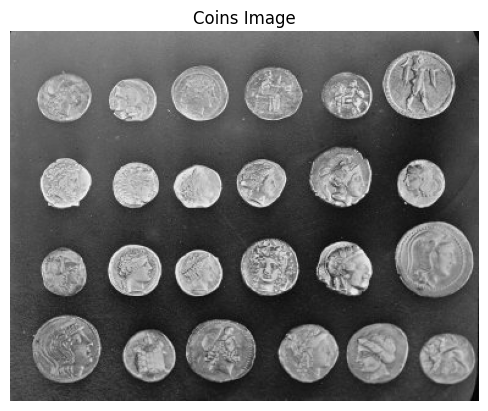

Image size: (303, 384)
Minimum grayscale value: 1
Maximum grayscale value: 252


In [12]:
# Load and visualize the 'coins' image from skimage

from skimage import data
import matplotlib.pyplot as plt
import numpy as np

# Load image
coins = data.coins()

# Display image
plt.imshow(coins, cmap='gray')
plt.title("Coins Image")
plt.axis('off')
plt.show()

# image size
print("Image size:", coins.shape)

#  grayscale range
print("Minimum grayscale value:", np.min(coins))
print("Maximum grayscale value:", np.max(coins))

2.


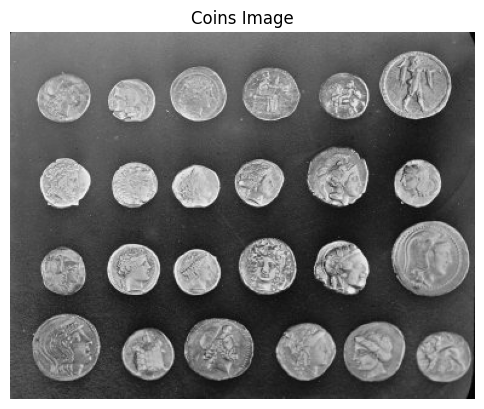

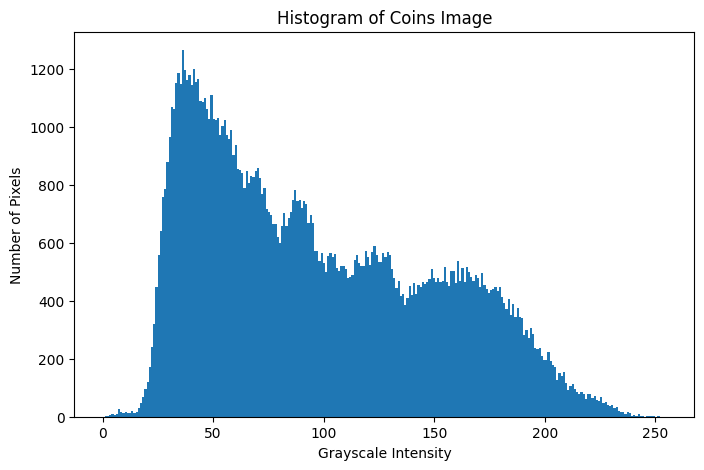

In [13]:
# Display image
plt.figure(figsize=(6,6))
plt.imshow(coins, cmap='gray')
plt.title("Coins Image")
plt.axis('off')
plt.show()

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(coins.ravel(), bins=256, range=(0,255))
plt.title("Histogram of Coins Image")
plt.xlabel("Grayscale Intensity")
plt.ylabel("Number of Pixels")
plt.show()

Explanation:
The histogram shows how many pixels exist for each grayscale intensity value (0 = black, 255 = white).

For the coins image, the peaks usually correspond to different regions:

Dark intensity peak (left side of histogram)
Represents the darker background and shadow regions between the coins.
Middle intensity peak
Corresponds to the gray metallic surfaces of the coins and textured regions.
Bright intensity peak (right side)
Represents highlights and reflective parts of the coins where light is strongest.
So the histogram reflects the composition of the image:
Background → darker pixels
Coin surfaces → medium gray pixels
Reflections/highlights → bright pixels


3.


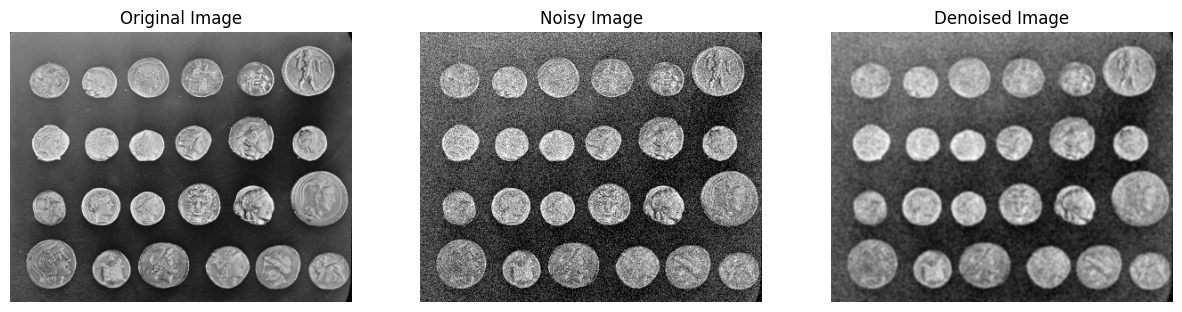

In [14]:
from skimage import data, util, filters

# Add noise to the image
noisy_image = util.random_noise(coins, mode='gaussian')

# Remove noise using Gaussian filter
denoised_image = filters.gaussian(noisy_image, sigma=1)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(noisy_image, cmap='gray')
axes[1].set_title("Noisy Image")
axes[1].axis('off')

axes[2].imshow(denoised_image, cmap='gray')
axes[2].set_title("Denoised Image")
axes[2].axis('off')

plt.show()

As we can see, the noised image contains random bright/dark ppixels while the denoised is smoother.

random_noise(mode='gaussian') adds Gaussian noise to the image.

filters.gaussian() smooths the image and reduces the noise.

sigma=1 controls the strength of the smoothing, the smaller it is , the less smoothing is applied

4.

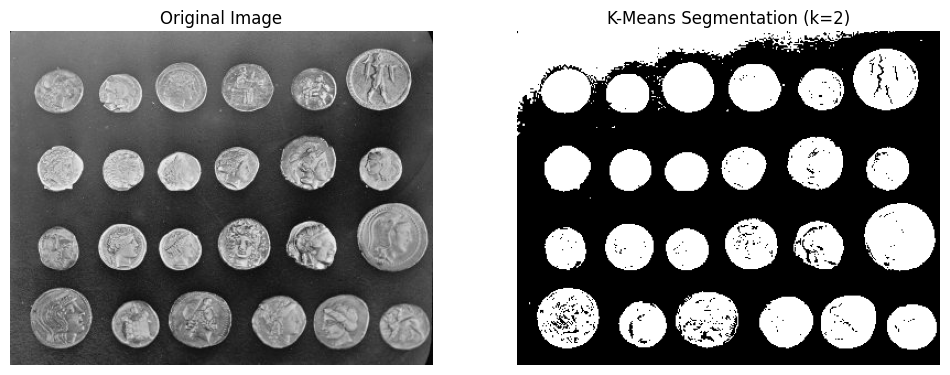

In [15]:
from skimage import data
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Reshape image into a list of pixels
pixels = coins.reshape(-1, 1)

# Apply K-Means clustering with k = 2
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(pixels)

# Get clustered labels
labels = kmeans.labels_

# Reshape labels back to image shape
segmented = labels.reshape(coins.shape)

# Display original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(segmented, cmap='gray')
axes[1].set_title("K-Means Segmentation (k=2)")
axes[1].axis('off')

plt.show()

The algorithm KMeans(n_clusters=2) separates the pixels into 2 groups:
one cluster usually corresponds to the background the other corresponds to the coins
The segmented image shows these two regions with different colors/intensities.

5.

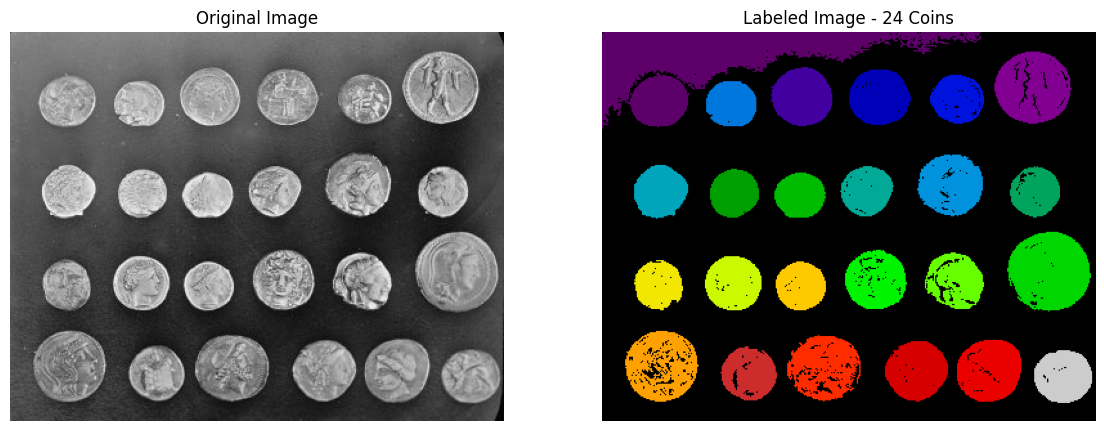

Number of coins detected: 24


In [16]:
from skimage import data, filters, measure, morphology

# Threshold the image to create a binary mask
threshold = filters.threshold_otsu(coins)
binary = coins > threshold

# Remove small objects/noise
binary_clean = morphology.remove_small_objects(binary, min_size=100)

# Label connected components
labeled_image = measure.label(binary_clean)

# This is for counting objects
num_coins = labeled_image.max()

# Display original and labeled images
fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(labeled_image, cmap='nipy_spectral')
axes[1].set_title(f"Labeled Image - {num_coins} Coins")
axes[1].axis('off')

plt.show()

# Print number of coins
print("Number of coins detected:", num_coins)

The image becomes binary:
coins are white and background is black

measure.label() assigns a different label/color to each connected object

labeled_image.max() gives the total number of detected coins

6.

      Area  Major Axis Length  Orientation
0   8755.0         291.294551    -1.423307
1   2459.0          59.966495     1.552547
2   1684.0          47.400067     1.330651
3   1631.0          47.608317     1.560757
4   1193.0          41.310433     1.383445
5   1133.0          39.977857     1.446910
6   1834.0          51.413541     1.532118
7   1325.0          42.451724    -0.883311
8   1203.0          40.921169    -1.034534
9   1133.0          39.719469    -0.873364
10  1129.0          39.179294    -0.923138
11  1104.0          39.634983    -1.500398
12  3054.0          64.238604     1.321690
13  1633.0          48.455200    -1.482099
14  1352.0          47.315544     0.943862
15  1461.0          44.279748     1.510757
16  1095.0          37.726049    -1.098781
17  1148.0          39.093268     1.512176
18  2099.0          58.230243    -1.108783
19  1954.0          55.822104    -1.406812
20  1918.0          52.847912    -0.985728
21  1728.0          48.536525    -1.134875
22  1312.0 

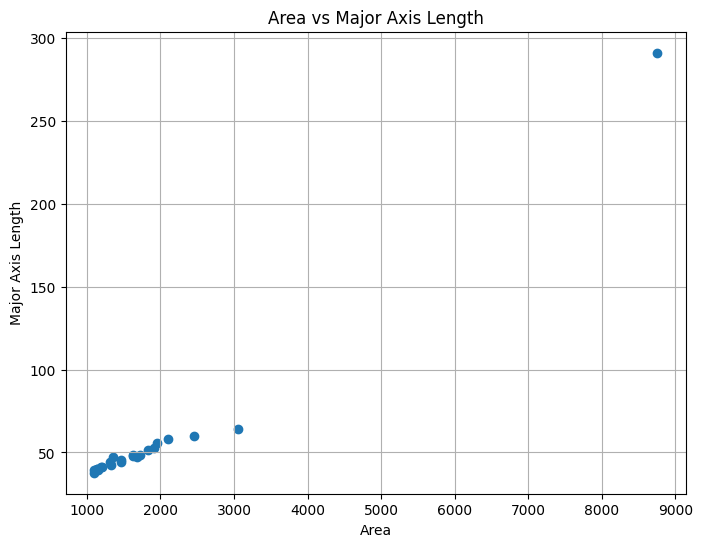

In [17]:
import pandas as pd

# Threshold image
threshold = filters.threshold_otsu(coins)
binary = coins > threshold

# Remove small noisy objects
binary = morphology.remove_small_objects(binary, min_size=100)

# Label connected components
labeled = measure.label(binary)

# Extract region properties
regions = measure.regionprops(labeled)

# Store features
areas = []
major_axis_lengths = []
orientations = []

for region in regions:
    areas.append(region.area)
    major_axis_lengths.append(region.major_axis_length)
    orientations.append(region.orientation)

# Compute averages
avg_area = np.mean(areas)
avg_major_axis = np.mean(major_axis_lengths)
avg_orientation = np.mean(orientations)

# Create dataframe
df = pd.DataFrame({
    "Area": areas,
    "Major Axis Length": major_axis_lengths,
    "Orientation": orientations
})

# Display extracted features
print(df)

# Print averages
print("\nAverage Area:", avg_area)
print("Average Major Axis Length:", avg_major_axis)
print("Average Orientation:", avg_orientation)

# Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(areas, major_axis_lengths)

plt.xlabel("Area")
plt.ylabel("Major Axis Length")
plt.title("Area vs Major Axis Length")
plt.grid(True)

plt.show()

Explanation of Features
Area is the number of pixels belonging to each coin
Major Axis Length is the length of the longest axis of the ellipse fitted to the coin
Orientation is the angle showing the direction of the coin’s major axis.

The scatter plot shows a positive relationship between the coin area and the major axis length, as the area increases, the major axis length also increases.

Most coins are grouped together with similar sizes, while one point appears far from the others, indicating a much larger detected object or possibly a merged/incorrectly segmented coin region (an outlier) which in our case can be seen in the up corner.

7.


Number of coins with area > 1750 pixels: 7


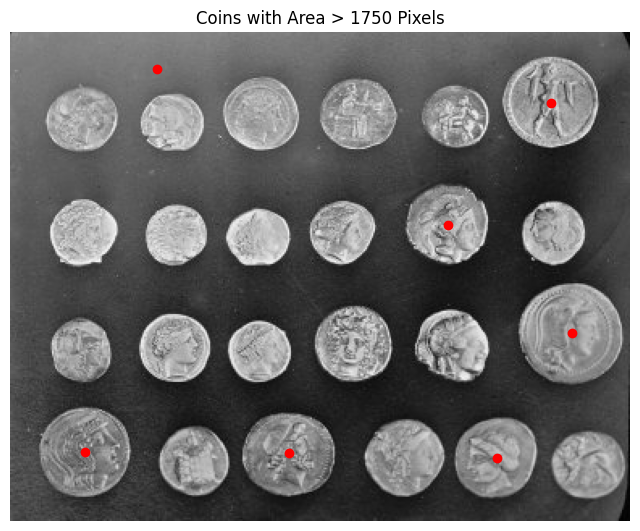

In [18]:
from skimage import data, filters, measure, morphology
import matplotlib.pyplot as plt

# Threshold image
threshold = filters.threshold_otsu(coins)
binary = coins > threshold

# Remove small objects
binary = morphology.remove_small_objects(binary, min_size=100)

# Label connected regions
labeled = measure.label(binary)

# Extract region properties
regions = measure.regionprops(labeled)

# Filter regions with area > 1750
large_coins = [region for region in regions if region.area > 1750]

# Count them
count_large_coins = len(large_coins)

print("Number of coins with area > 1750 pixels:", count_large_coins)

# Optional: display these regions
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(coins, cmap='gray')

for region in large_coins:
    y, x = region.centroid
    ax.plot(x, y, 'ro')

plt.title("Coins with Area > 1750 Pixels")
plt.axis('off')
plt.show()

measure.regionprops() extracts properties for each labeled coin.

The list comprehension:

[region for region in regions if region.area > 1750]

keeps only coins whose area is larger than 1750 pixels.

len(large_coins) gives the number of such coins.

8.

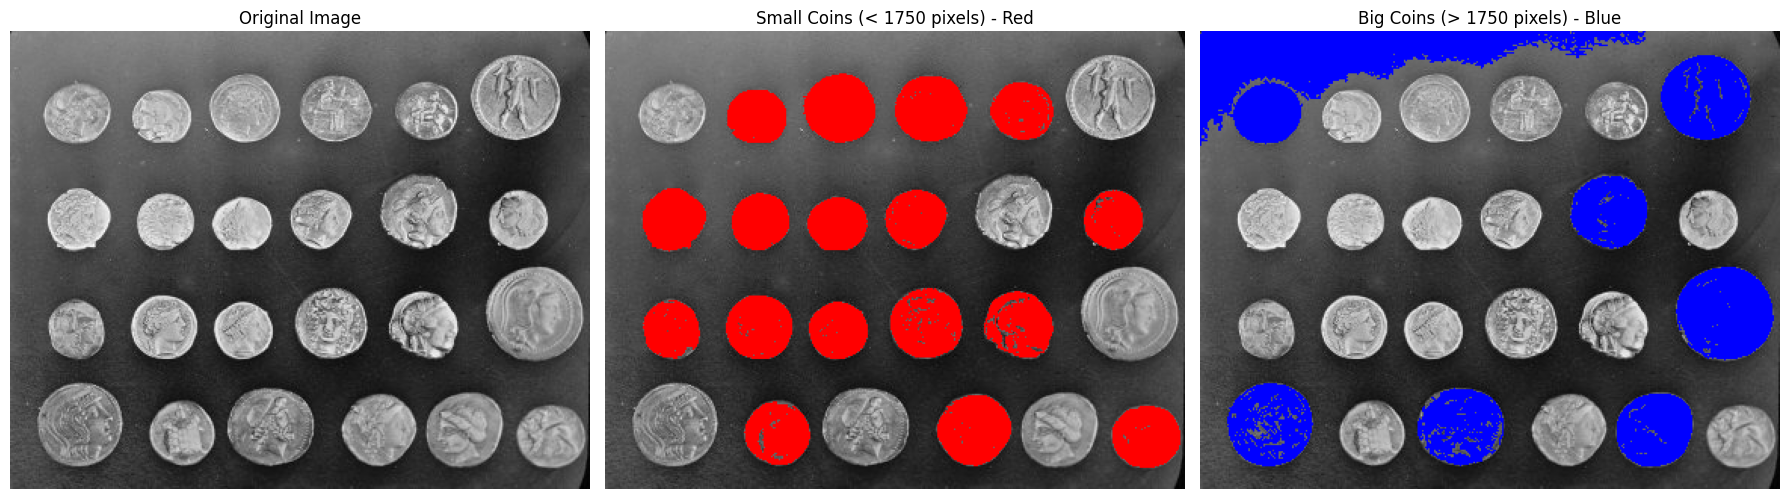

In [19]:
from skimage import data, filters, measure, morphology, color
import matplotlib.pyplot as plt
import numpy as np

# Threshold image
threshold = filters.threshold_otsu(coins)
binary = coins > threshold

# Remove small objects
binary = morphology.remove_small_objects(binary, min_size=100)

# Label connected regions
labeled = measure.label(binary)

# Create RGB versions for coloring
small_coins_img = color.gray2rgb(coins)
big_coins_img = color.gray2rgb(coins)

# Loop through regions
regions = measure.regionprops(labeled)

for region in regions:

    # Coordinates of the region
    coords = region.coords

    if region.area < 1750:
        # Color small coins red
        small_coins_img[coords[:, 0], coords[:, 1]] = [255, 0, 0]

    elif region.area > 1750:
        # Color big coins blue
        big_coins_img[coords[:, 0], coords[:, 1]] = [0, 0, 255]

# Create 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Original image
axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Small coins
axes[1].imshow(small_coins_img)
axes[1].set_title("Small Coins (< 1750 pixels) - Red")
axes[1].axis('off')

# Big coins
axes[2].imshow(big_coins_img)
axes[2].set_title("Big Coins (> 1750 pixels) - Blue")
axes[2].axis('off')

plt.tight_layout()
plt.show()

The figure successfully separates the coins based on their area. Small coins (area < 1750 pixels) are highlighted in red, while large coins (area > 1750 pixels) are highlighted in blue. This shows that region properties such as area can be used to classify objects of different sizes in an image.

9.

The main steps for the task of segmentation using an unsupervised learning algorithm are :      
1. Loading the RGB image
Read the image and represent it as a 3D matrix containing Red, Green, and Blue channels.
2. Image Preprocessing
Normalize pixel values if necessary.
Reshape the image from (height, width, 3) into a 2D array where each pixel is a feature vector rgb.
3. Applying an Unsupervised Learning algorithm like K-Means, DBScan, Fuzzy C-Means , GMM or Agglomeerative Clustering.
4. Assign labels to pixels
Each pixel receives a cluster label corresponding to a segmented region.
5. Reconstruct the segmented image
Replace each pixel with its cluster centroid color, or a representative color for visualization.
6. Visualize and evaluate results
Compare the segmented image with the original image to analyze region separation and object boundaries.

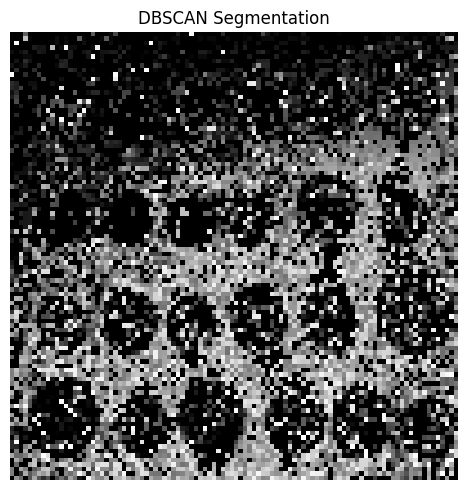

In [20]:
from skimage import data, transform
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Load coins image
coins = data.coins()

# Resize image to reduce RAM usage
small_coins = transform.resize(coins, (100, 100), anti_aliasing=True)

# Reshape into pixel vectors
pixels = small_coins.reshape(-1, 1)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.0001, min_samples=5)
labels = dbscan.fit_predict(pixels)

# Reshape labels back to image
segmented = labels.reshape(small_coins.shape)

# Display DBSCAN result only
plt.figure(figsize=(6, 5))
plt.imshow(segmented, cmap='gray')
plt.title("DBSCAN Segmentation")
plt.axis('off')
plt.tight_layout()
plt.show()

This result shows that lowering eps made DBSCAN more sensitive to small intensity differences. Instead of forming clear coin regions, the algorithm produced many tiny fragmented clusters and noisy pixels.

The coins are only partially visible, and the segmentation appears scattered and unstable. This demonstrates that DBSCAN can be difficult to tune for image segmentation, especially for grayscale images where pixel intensities change gradually.

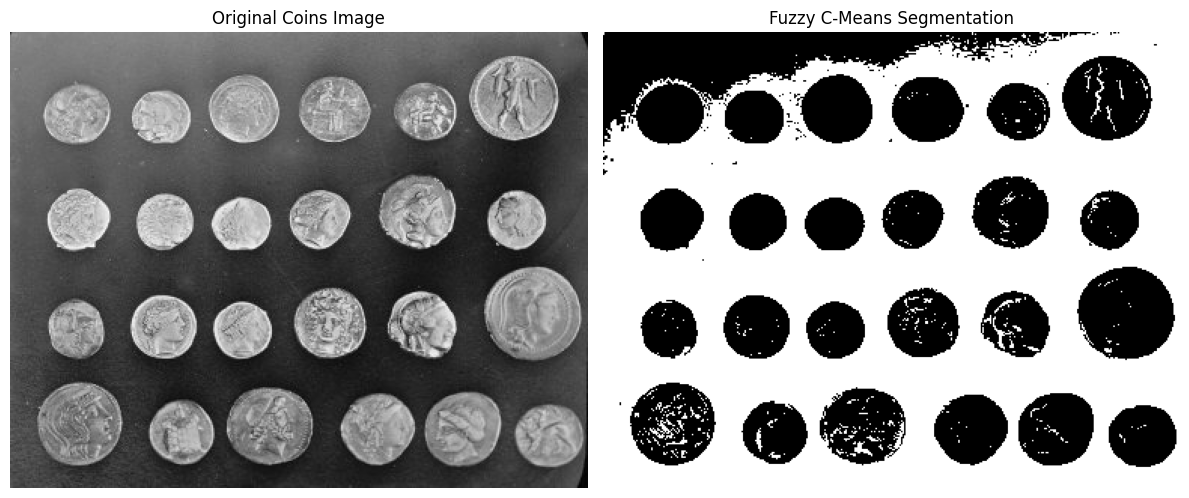

In [21]:
!pip install -q scikit-fuzzy

from skimage import data
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import numpy as np

# Reshape image into pixel vectors
pixels = coins.reshape(-1, 1)

# Normalize pixel values
pixels_norm = pixels / 255.0

# Transpose data for Fuzzy C-Means
# Required shape: features x samples
data_fcm = pixels_norm.T

# Apply Fuzzy C-Means clustering
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_fcm,
    c=2,          # number of clusters
    m=2,          # fuzziness parameter
    error=0.005,
    maxiter=1000
)

# Get cluster labels
labels = np.argmax(u, axis=0)

# Reshape labels back into image shape
segmented = labels.reshape(coins.shape)

# Display original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Coins Image")
axes[0].axis('off')

axes[1].imshow(segmented, cmap='gray')
axes[1].set_title("Fuzzy C-Means Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()

The Fuzzy C-Means segmentation here shows mixed results — it works reasonably well on some coins but struggles significantly with others.
 Coins in the top-right rows are segmented cleanly as solid blobs, but uneven lighting causes heavy background leakage at the top, and engraved reliefs create holes and fragmentation in the bottom rows. Edges are also jagged rather than smoothly circular.


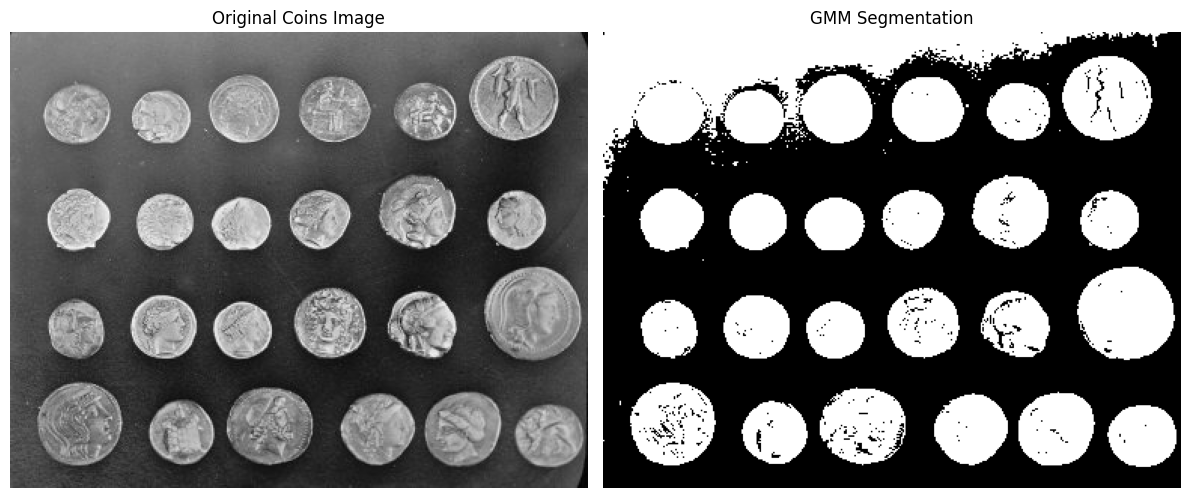

In [7]:
from sklearn.mixture import GaussianMixture

# Reshape image into pixel vectors
pixels = coins.reshape(-1, 1)

# Normalize pixel values
pixels_norm = pixels / 255.0

# Apply Gaussian Mixture Model (GMM)
gmm = GaussianMixture(
    n_components=2,   # number of clusters
    random_state=0
)

# Predict cluster labels
labels = gmm.fit_predict(pixels_norm)

# Reshape labels back into image shape
segmented = labels.reshape(coins.shape)

# Display original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(coins, cmap='gray')
axes[0].set_title("Original Coins Image")
axes[0].axis('off')

axes[1].imshow(segmented, cmap='gray')
axes[1].set_title("GMM Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()

The GMM segmentation gives fairly good results overall, with most coins clearly separated from the background as solid white shapes, especially in the middle two rows where the coins appear clean and well-defined.

However, the top row still suffers from background leakage due to the brighter, uneven lighting in that area, where parts of the background get grouped together with the coins.

In general, GMM handles the intensity distribution better than a hard clustering method.

10.


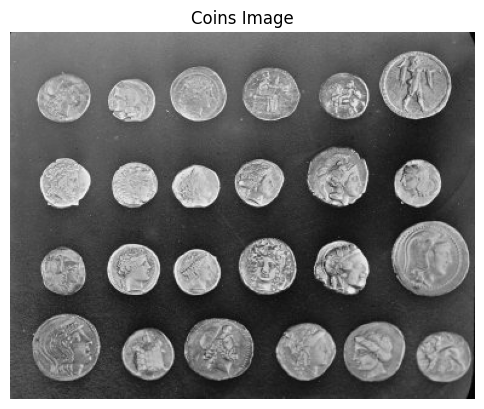

  Texture Feature       Value
0        Contrast  351.845453
1   Dissimilarity    9.292566
2     Homogeneity    0.238239
3          Energy    0.019559
4     Correlation    0.937166
5             ASM    0.000383


In [10]:
from skimage import data, feature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Compute Gray-Level Co-occurrence Matrix (GLCM)
glcm = feature.graycomatrix(
    coins,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

# Extract texture features
contrast = feature.graycoprops(glcm, 'contrast')[0, 0]
dissimilarity = feature.graycoprops(glcm, 'dissimilarity')[0, 0]
homogeneity = feature.graycoprops(glcm, 'homogeneity')[0, 0]
energy = feature.graycoprops(glcm, 'energy')[0, 0]
correlation = feature.graycoprops(glcm, 'correlation')[0, 0]
ASM = feature.graycoprops(glcm, 'ASM')[0, 0]

# Store results in a table
features = pd.DataFrame({
    'Texture Feature': [
        'Contrast',
        'Dissimilarity',
        'Homogeneity',
        'Energy',
        'Correlation',
        'ASM'
    ],
    'Value': [
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation,
        ASM
    ]
})

# Display image
plt.figure(figsize=(6,6))
plt.imshow(coins, cmap='gray')
plt.title("Coins Image")
plt.axis('off')
plt.show()

# Print texture features
print(features)